# LIBRARIES IMPORTATION

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                            confusion_matrix, ConfusionMatrixDisplay, classification_report, 
                            average_precision_score, precision_recall_curve)

import warnings
warnings.filterwarnings("ignore")

In [2]:
pd.set_option("display.max.column", 32)

# DATA IMPORTATION AND AUDITING

In [3]:
fraud = pd.read_csv("../creditcard.csv")
fraud.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
fraud.shape

(284807, 31)

In [5]:
fraud.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
fraud.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
fraud.duplicated().sum()

np.int64(1081)

In [8]:
fraud[["Time", "Amount"]].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


### Insight

The dataset contains **284,807 transaction records and 31 columns**. Of these, **28 columns (V1–V28)** contain anonymized numerical features, while **Time**, **Amount**, and **Class** provide additional information about each transaction. The **Time** column represents the number of seconds elapsed between each transaction and the first transaction in the dataset. The **Amount** column indicates the monetary value of each transaction, while the **Class** column identifies whether a transaction is **legitimate (non-fraudulent)** or **fraudulent**.

The dataset contains **no missing values**, indicating that all records have complete information across the available features. However, approximately **1,081 duplicate records** were identified, which will be removeed during the data-cleaning stage to avoid potential bias in the analysis.


In [9]:
df = fraud.copy()

# Data cleaning

In [10]:
df.drop_duplicates(inplace = True)

# Analysis

In [11]:
class_perc = df["Class"].value_counts(normalize = True) * 100
class_perc

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

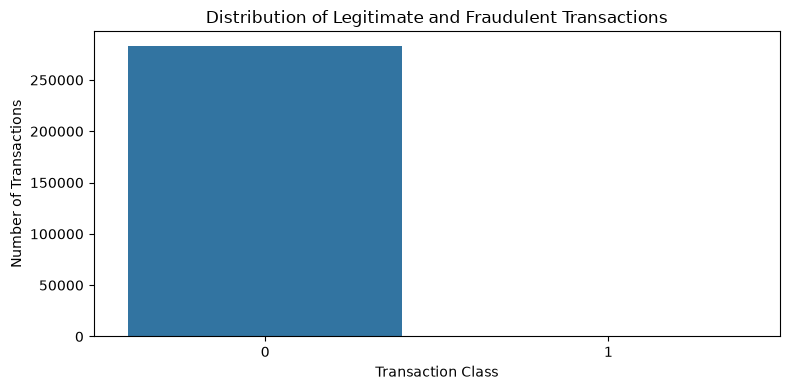

In [12]:
plt.figure(figsize = (8, 4))
sns.countplot(data = df, x = "Class")
plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

### Insight: Fraud Rate

The dataset is **highly imbalanced**. Approximately **99.83% of the transactions are legitimate (Class 0)**, while only **0.17% are fraudulent (Class 1)**. This means fraudulent transactions make up a very small proportion of the dataset.

In [13]:
# Convert time to hours (0-23)
df["Hour"] = (df["Time"] // 3600) % 24

In [14]:
df["Hour"].tail()

284802    23.0
284803    23.0
284804    23.0
284805    23.0
284806    23.0
Name: Hour, dtype: float64

In [15]:
# Looking at transaction hours 
hourly_trans = (df.groupby("Hour").size()
                .reset_index(name = "Transaction_Count")
                 .sort_values("Transaction_Count", ascending=False))
hourly_trans

,Hour,Transaction_Count
21,21.0,17629
18,18.0,16959
11,11.0,16781
20,20.0,16705
10,10.0,16548
14,14.0,16520
16,16.0,16396
15,15.0,16374
17,17.0,16130
9,9.0,15767


### Insight

The highest number of transactions occurred at **Hour 21**, with a total of **17,629 transactions**. This indicates that Hour 21 had the highest transaction volume in the dataset.


In [16]:
fraud_by_hour = (
    df.groupby("Hour")["Class"].mean().mul(100)
      .reset_index(name="Fraud_Rate")
      .sort_values("Fraud_Rate", ascending=False))
fraud_by_hour

,Hour,Fraud_Rate
2,2.0,1.451028
4,4.0,1.043557
3,3.0,0.487525
5,5.0,0.368139
7,7.0,0.317987
11,11.0,0.315833
1,1.0,0.237643
6,6.0,0.220480
17,17.0,0.173590
18,18.0,0.165104


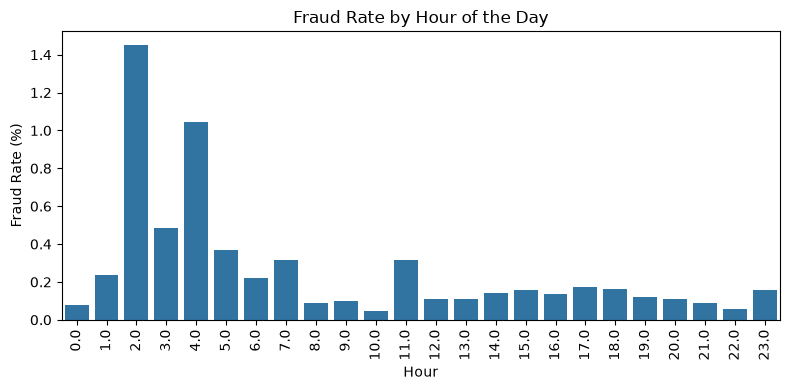

In [17]:
plt.figure(figsize=(8, 4))
sns.barplot(data = fraud_by_hour, x = "Hour", y = "Fraud_Rate")
plt.title("Fraud Rate by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

### Insight: Fraud Rate by Hour

Fraud rates varied across hours, with the **highest rate at Hour 2 (1.45%)** and the **lowest at Hour 10 (0.05%)**. This suggests that fraud occurrence was not evenly distributed across the observed time periods.


In [18]:
# comparing transaction amounts for fraudulent vs. legitimate transactions.
trans_amount = df.groupby("Class")["Amount"].describe()
trans_amount

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


### Insight
Fraudulent transactions have a higher average amount (123.87) than legitimate transactions (88.41), but a lower median amount (9.82 vs. 22.00). This suggests that fraudulent transaction amounts are highly variable, with a few unusually large transactions increasing the average.


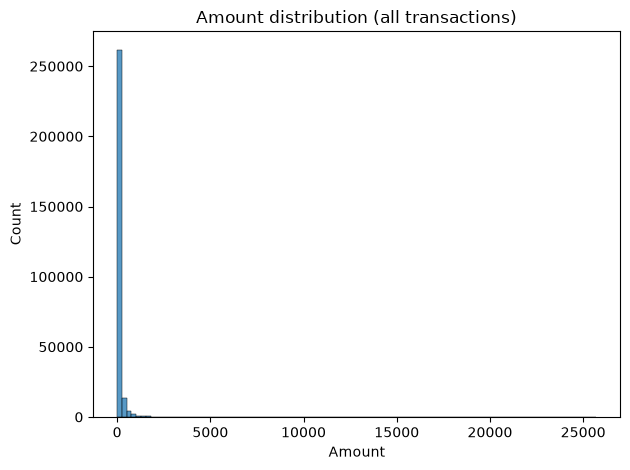

In [19]:
sns.histplot(df["Amount"], bins=100)
plt.title("Amount distribution (all transactions)")
plt.tight_layout()
plt.show()


# Insight:
Amount is right skewed which most transactions are smaller and there are few larger transactions.

# DATA PREPROCESSING

In [20]:
X = df.drop(columns = ["Class", "Hour"])
y = df["Class"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, 
                                                   random_state = 42, stratify = y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape) 

(198608, 30) (85118, 30) (198608,) (85118,)


In [22]:
print(y_train.value_counts(normalize=True) * 100)
print(y_test.value_counts(normalize=True) * 100)

Class
0    99.83334
1     0.16666
Name: proportion, dtype: float64
Class
0    99.833173
1     0.166827
Name: proportion, dtype: float64


In [23]:
scale_cols = ["Amount", "Time"]

preprocessor = ColumnTransformer(transformers = [("scaler", StandardScaler(), scale_cols)],
    remainder = "passthrough")

# MODEL DEFINITION

In [24]:
models = {
    "LogReg" : lambda cw = None: LogisticRegression(max_iter = 2000, 
                                                   class_weight = cw, random_state = 42),
    "DecisionTree" : lambda cw = None: DecisionTreeClassifier(max_depth = 8, min_samples_leaf = 5,
                                                   class_weight = cw, random_state = 42),
    "RandomForest" : lambda cw = None: RandomForestClassifier(n_estimators = 200, n_jobs = -1, 
                                                   class_weight = cw, random_state = 42)
}


# PIPELINE

In [25]:
pipelines = {}

for model_name, create_model in models.items():
    # Baseline
    pipelines[f"{model_name} | baseline"] = ImbPipeline([
        ("preprocessor", preprocessor),("clf", create_model())])
    # Class weight
    pipelines[f"{model_name} | class_weight"] = ImbPipeline([
        ("preprocessor", preprocessor), ("clf", create_model("balanced"))])
    # SMOTE + undersampling
    pipelines[f"{model_name} | smote"] = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(sampling_strategy = 0.1, k_neighbors = 3, random_state = 42)),
        ("under", RandomUnderSampler(sampling_strategy = 0.5, random_state = 42)),
        ("clf", create_model())
    ])

For each model, the function for creating the model, control how much importance is given to each class. Storing all the model to a pipeline where clf is the classifier.

In [26]:
# splitting the training into 5 parts.
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

scoring = {"pr_auc": "average_precision",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"}
# Store result
rows = []
for model_name, pipeline in pipelines.items():
    cv_results = cross_validate(pipeline, X_train, y_train, cv = cv, scoring = scoring, n_jobs = -1)
    rows.append({
        "config": model_name,
        "pr_auc": cv_results["test_pr_auc"].mean(),
        "recall": cv_results["test_recall"].mean(),
        "precision": cv_results["test_precision"].mean(),
        "f1": cv_results["test_f1"].mean()
    })
results = pd.DataFrame(rows)


In [46]:
results = results.sort_values(["pr_auc", "recall"], ascending = [False, False])
results

,config,pr_auc,recall,precision,f1
6,RandomForest | baseline,0.844472,0.758345,0.937115,0.837772
7,RandomForest | class_weight,0.844148,0.797739,0.923351,0.855478
8,RandomForest | smote,0.829255,0.843012,0.773282,0.805929
3,DecisionTree | baseline,0.760128,0.767662,0.894672,0.824049
0,LogReg | baseline,0.755245,0.631434,0.875065,0.731421
2,LogReg | smote,0.753894,0.888422,0.102018,0.182593
1,LogReg | class_weight,0.753450,0.912528,0.056089,0.105634
4,DecisionTree | class_weight,0.510071,0.836861,0.125300,0.214399
5,DecisionTree | smote,0.485179,0.842967,0.092630,0.166558


In [48]:
# Choosing the best configuration using the average precision score
best_config  =  "RandomForest | class_weight"
print(f"Best Configuration {best_config}")

Best Configuration RandomForest | class_weight


In [49]:
# Get the correcponding pipeline for the best configuration
best_pipeline = pipelines[best_config]
best_pipeline

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The gi

In [30]:
y_train_proba = cross_val_predict(best_pipeline, X_train, y_train, cv = cv, 
                                 method = "predict_proba", n_jobs = -1)[:, 1]

In [31]:
pr_auc = average_precision_score(y_train, y_train_proba)
print(f"PR-AUC: {pr_auc:.4f}")

PR-AUC: 0.8439


In [32]:
# Tune treshold
thresholds = np.arange(0.01, 1.00, 0.01)
threshold_results = []

for threshold in thresholds:
    y_train_pred = (y_train_proba > threshold).astype(int)
    threshold_results.append({
        "Threshold" : threshold, 
        "Accuracy" : accuracy_score(y_train, y_train_pred),
        "Recall" : recall_score(y_train, y_train_pred, zero_division = 0), 
        "Precision" : precision_score(y_train, y_train_pred, zero_division = 0), 
        "F1" : f1_score(y_train, y_train_pred, zero_division = 0) 
    })
threshold_results = pd.DataFrame(threshold_results)
threshold_results.head()

,Threshold,Accuracy,Recall,Precision,F1
0,0.01,0.993097,0.873112,0.178616,0.296562
1,0.02,0.996747,0.867069,0.322835,0.470492
2,0.03,0.997885,0.858006,0.432268,0.574899
3,0.04,0.998384,0.854985,0.508993,0.638106
4,0.05,0.998736,0.854985,0.582305,0.692778


In [42]:
qualified = threshold_results[
    (threshold_results["Recall"] >= 0.80) & (threshold_results["Precision"] >= 0.80)]
qualified.head()

,Threshold,Accuracy,Recall,Precision,F1
15,0.16,0.999391,0.845921,0.800000,0.822320
16,0.17,0.999416,0.845921,0.811594,0.828402
17,0.18,0.999431,0.845921,0.818713,0.832095
18,0.19,0.999446,0.842900,0.827893,0.835329
19,0.20,0.999456,0.842900,0.832836,0.837838


In [34]:
# From the qualified thresholds, select the one with the highest recall
best_threshold = qualified.loc[ qualified["Recall"].idxmax(), "Threshold"]
print(f"Best threshold {best_threshold:.2f}")

Best threshold 0.16


In [35]:
# Fit the model with the training data
best_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount']"
n_features_in_,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [36]:
y_test_proba = best_pipeline.predict_proba(X_test)[:, 1]

In [37]:
y_test_pred = (y_test_proba >= best_threshold).astype(int)

# MODEL EVALUATION

In [38]:
final_metrics = {
    "Accuracy" : accuracy_score(y_test, y_test_pred),
    "Recall" : recall_score(y_test, y_test_pred, zero_division = 0),
    "Precision" : precision_score(y_test, y_test_pred, zero_division = 0),
    "F1" : f1_score(y_test, y_test_pred, zero_division = 0),
    "Average Precision Score" : average_precision_score(y_test, y_test_pred)
}

In [39]:
final_metrics

{'Accuracy': 0.999424328579149,
 'Recall': 0.795774647887324,
 'Precision': 0.849624060150376,
 'F1': 0.8218181818181818,
 'Average Precision Score': 0.6764499907967371}

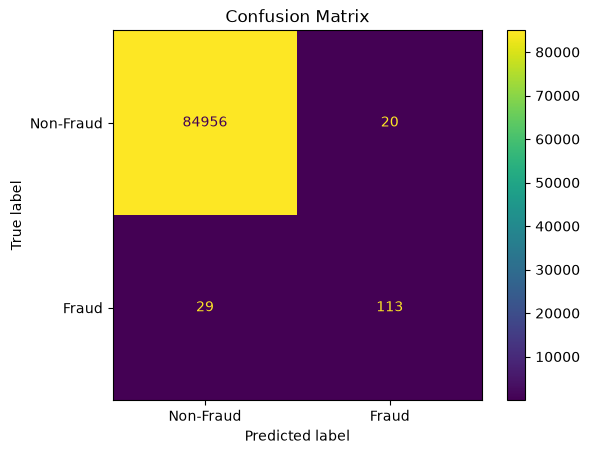

In [40]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, display_labels = ["Non-Fraud", "Fraud"])

plt.title("Confusion Matrix")
plt.show()

We:

1. Compared different models and sampling strategies.
2. Selected the best model using **PR-AUC**.
3. Generated cross-validated fraud probabilities.
4. Tuned the **classification threshold** instead of using 0.5 automatically.
5. Selected the threshold with the best **F1-score**.
6. Trained the final model on the full training data.
7. Evaluated it on the test set using **Accuracy, Precision, Recall, F1-score, and PR-AUC**, plus a confusion matrix.
